<a href="https://colab.research.google.com/github/Amri1003/Machine_Learning_Projects/blob/main/Creating_CohortOfSongs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import  pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.cluster import KMeans

print('Imported')






Imported


In [44]:
import warnings
warnings.filterwarnings('ignore')

In [45]:
# load the dataset

data=pd.read_csv('/content/rolling_stones_spotify.csv')

data






,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.9320,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.9610,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.9560,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.8950,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.9660,-5.098,0.0930,130.533,0.2060,32,305106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.9670,39,154080
1606,1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.4460,36,245266
1607,1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.8350,30,176080
1608,1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.5320,27,121680


1.	Initial data inspection and data cleaning:

a.	Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. Check for any instances of erroneous entries and rectify them as needed


In [46]:
# Are there any missing values? No
data.isnull().sum().any()

np.False_

In [47]:
# Check for duplicate rows
All_duplicateRows = data.duplicated().sum()
print(f"Number of duplicate rows: {All_duplicateRows}")


Number of duplicate rows: 0


In [48]:
# To check for erroneous data : No such data found
data.describe()

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


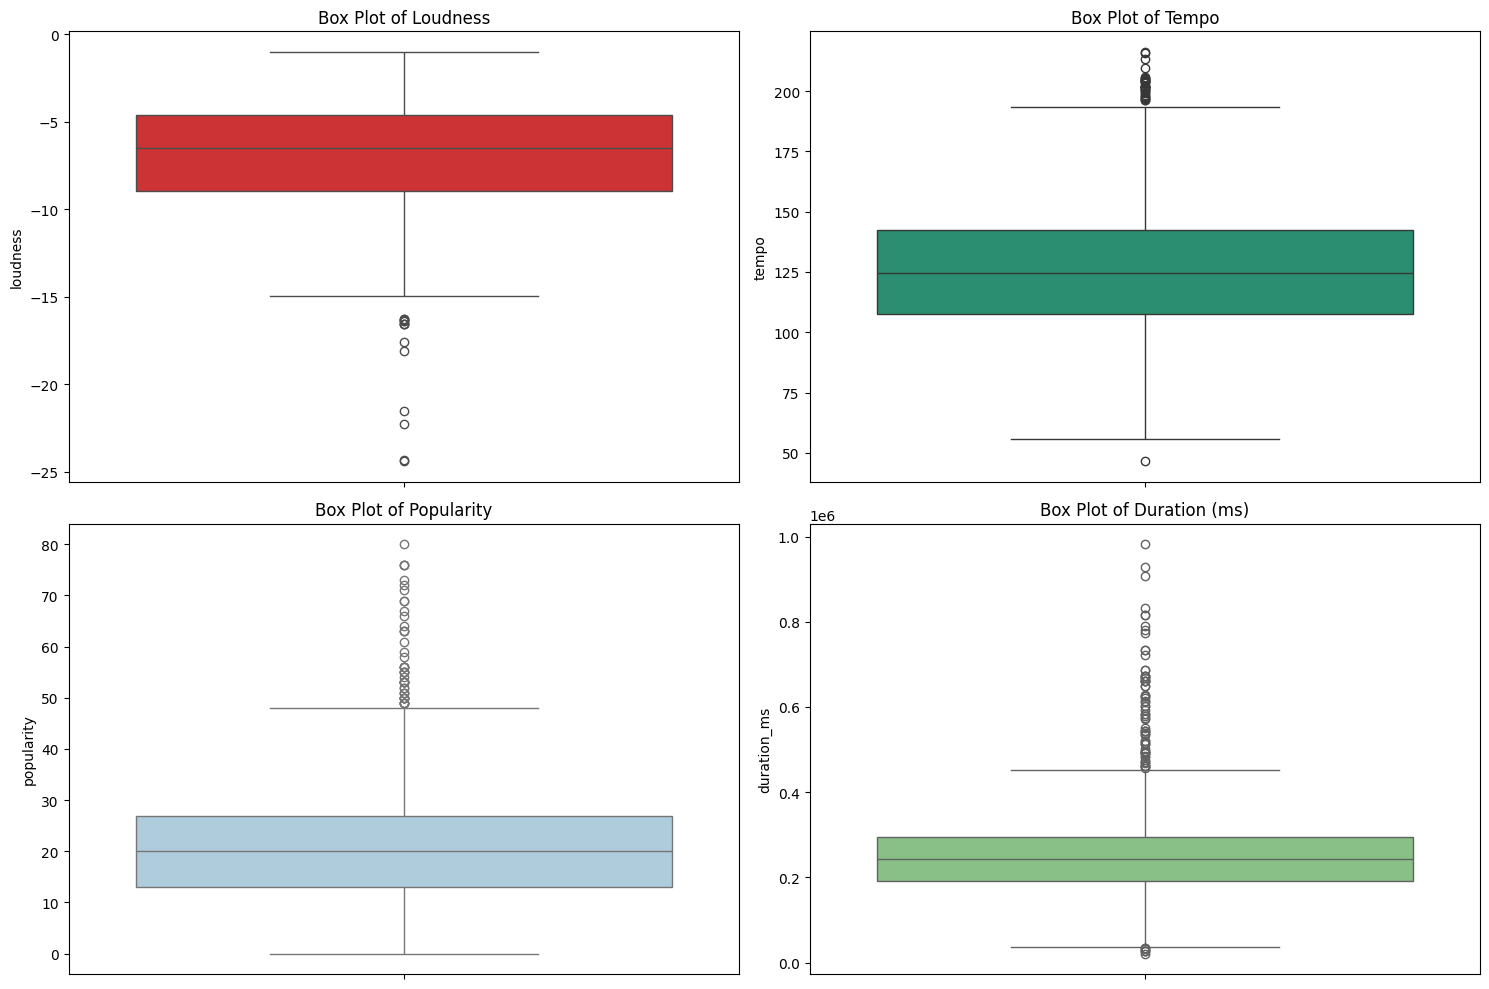

In [49]:
# To check for outliers for four important numerical values
# Observation : No such outliers as such which need to be taken care of

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(y=data['loudness'], palette='Set1')
plt.title('Box Plot of Loudness')
plt.ylabel('loudness')

plt.subplot(2, 2, 2)
sns.boxplot(y=data['tempo'], palette='Dark2')
plt.title('Box Plot of Tempo')
plt.ylabel('tempo')

plt.subplot(2, 2, 3)
sns.boxplot(y=data['popularity'], palette='Paired')
plt.title('Box Plot of Popularity')
plt.ylabel('popularity')

plt.subplot(2, 2, 4)
sns.boxplot(y=data['duration_ms'], palette='Accent')
plt.title('Box Plot of Duration (ms)')
plt.ylabel('duration_ms')

plt.tight_layout()
plt.show()

2.	Refine the data for further processing based on your findings

In [50]:
# Convert data type of release_date into day/time
data['release_date'] = pd.to_datetime(data['release_date'])
print(f"Data type of 'release_date' column after conversion: {data['release_date'].dtype}")

Data type of 'release_date' column after conversion: datetime64[ns]


3.	Perform exploratory data analysis and feature engineering


a.	Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album


b.	Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns


c.	Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved


d.	Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations


In [51]:
#a. Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album
#Identify Popular Songs and Count per Album

Top albums by number of popular songs (popularity >= 60):
album
Sticky Fingers (Remastered)                   3
Aftermath                                     2
Let It Bleed                                  2
Some Girls                                    2
Between The Buttons                           1
Out Of Our Heads                              1
Exile On Main Street (2010 Re-Mastered)       1
Bridges To Babylon (Remastered)               1
Tattoo You (2009 Re-Mastered)                 1
Beggars Banquet (50th Anniversary Edition)    1
Name: is_popular, dtype: int64


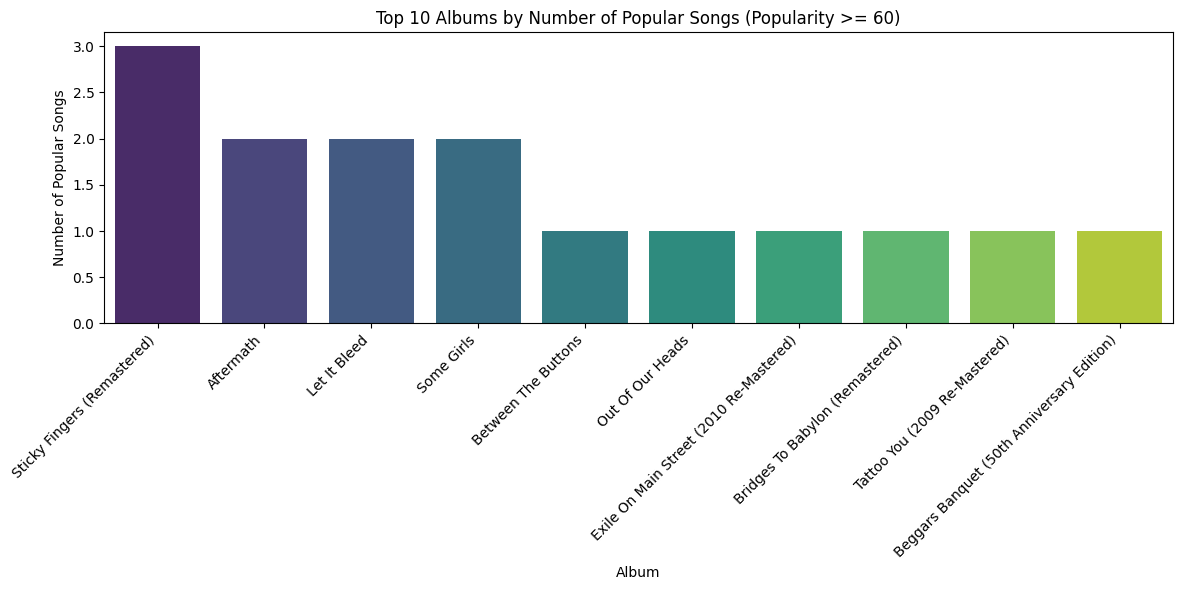

In [53]:
# find popular albums
data['is_popular'] = data['popularity'] >= 60
album_popular_songs = data.groupby('album')['is_popular'].sum().sort_values(ascending=False)

print("Top albums by number of popular songs (popularity >= 60):")
print(album_popular_songs.head(10))

# Visualize the top albums
plt.figure(figsize=(12, 6))
sns.barplot(x=album_popular_songs.head(10).index, y=album_popular_songs.head(10).values, palette='viridis')
plt.title('Top 10 Albums by Number of Popular Songs (Popularity >= 60)')
plt.xlabel('Album')
plt.ylabel('Number of Popular Songs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [54]:
#b.	Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns

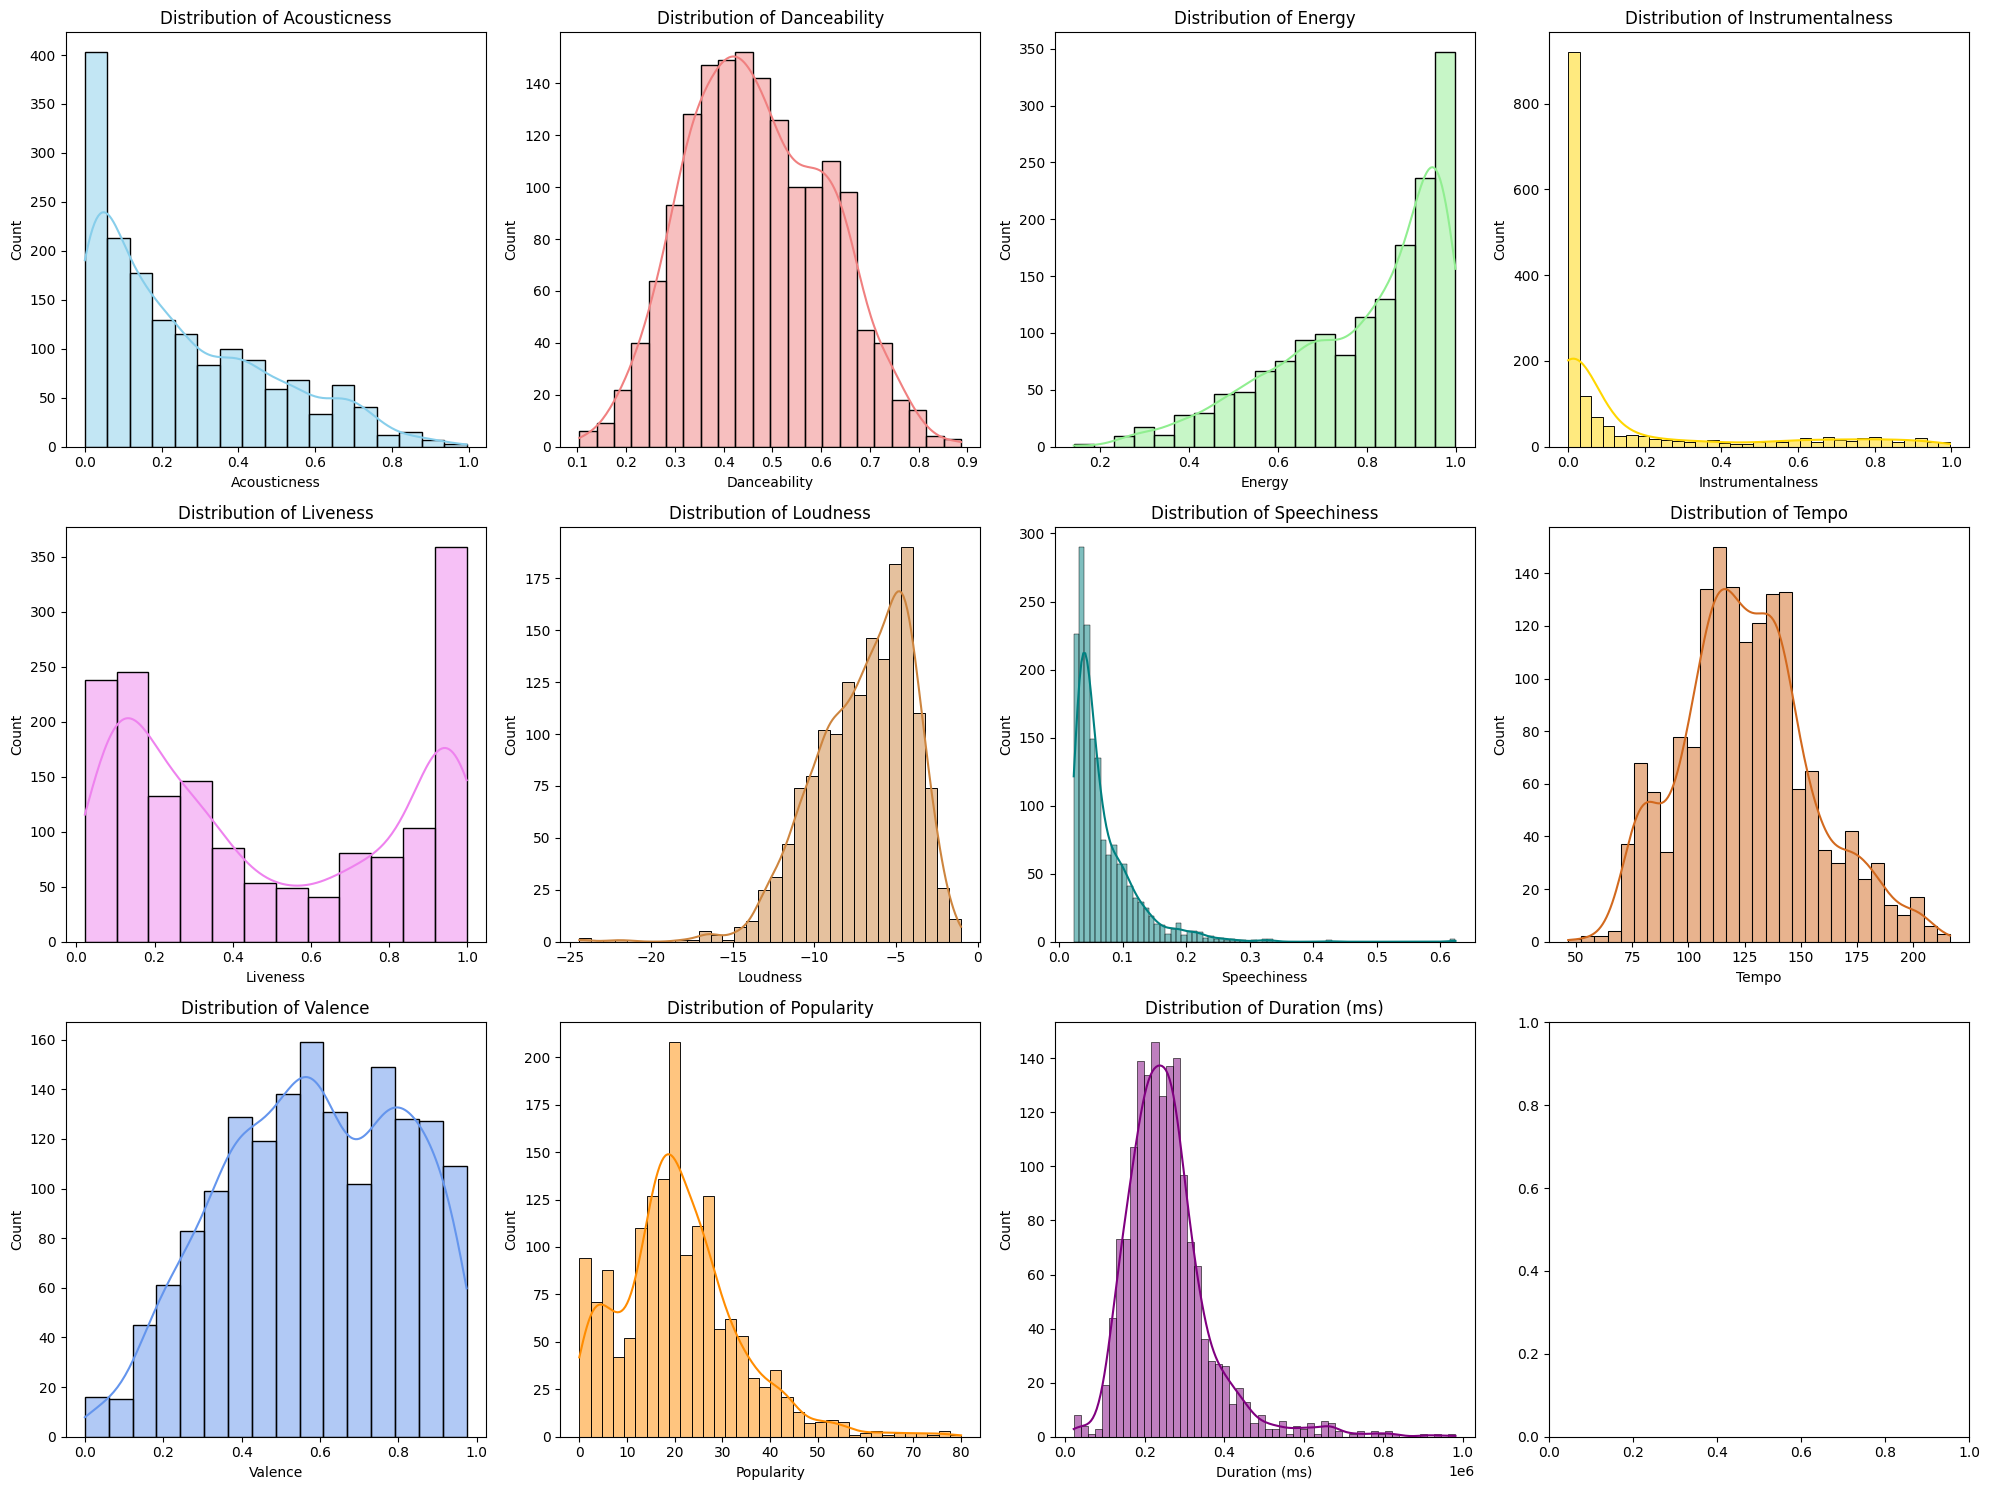

In [55]:
numerical_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness',
    'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms'
]

n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy indexing

# Plotting each histogram explicitly
sns.histplot(data['acousticness'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Acousticness')
axes[0].set_xlabel('Acousticness')

sns.histplot(data['danceability'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Danceability')
axes[1].set_xlabel('Danceability')

sns.histplot(data['energy'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Energy')
axes[2].set_xlabel('Energy')

sns.histplot(data['instrumentalness'], kde=True, ax=axes[3], color='gold')
axes[3].set_title('Distribution of Instrumentalness')
axes[3].set_xlabel('Instrumentalness')

sns.histplot(data['liveness'], kde=True, ax=axes[4], color='violet')
axes[4].set_title('Distribution of Liveness')
axes[4].set_xlabel('Liveness')

sns.histplot(data['loudness'], kde=True, ax=axes[5], color='peru')
axes[5].set_title('Distribution of Loudness')
axes[5].set_xlabel('Loudness')

sns.histplot(data['speechiness'], kde=True, ax=axes[6], color='teal')
axes[6].set_title('Distribution of Speechiness')
axes[6].set_xlabel('Speechiness')

sns.histplot(data['tempo'], kde=True, ax=axes[7], color='chocolate')
axes[7].set_title('Distribution of Tempo')
axes[7].set_xlabel('Tempo')

sns.histplot(data['valence'], kde=True, ax=axes[8], color='cornflowerblue')
axes[8].set_title('Distribution of Valence')
axes[8].set_xlabel('Valence')

sns.histplot(data['popularity'], kde=True, ax=axes[9], color='darkorange')
axes[9].set_title('Distribution of Popularity')
axes[9].set_xlabel('Popularity')

sns.histplot(data['duration_ms'], kde=True, ax=axes[10], color='purple')
axes[10].set_title('Distribution of Duration (ms)')
axes[10].set_xlabel('Duration (ms)')


plt.tight_layout()
plt.show()

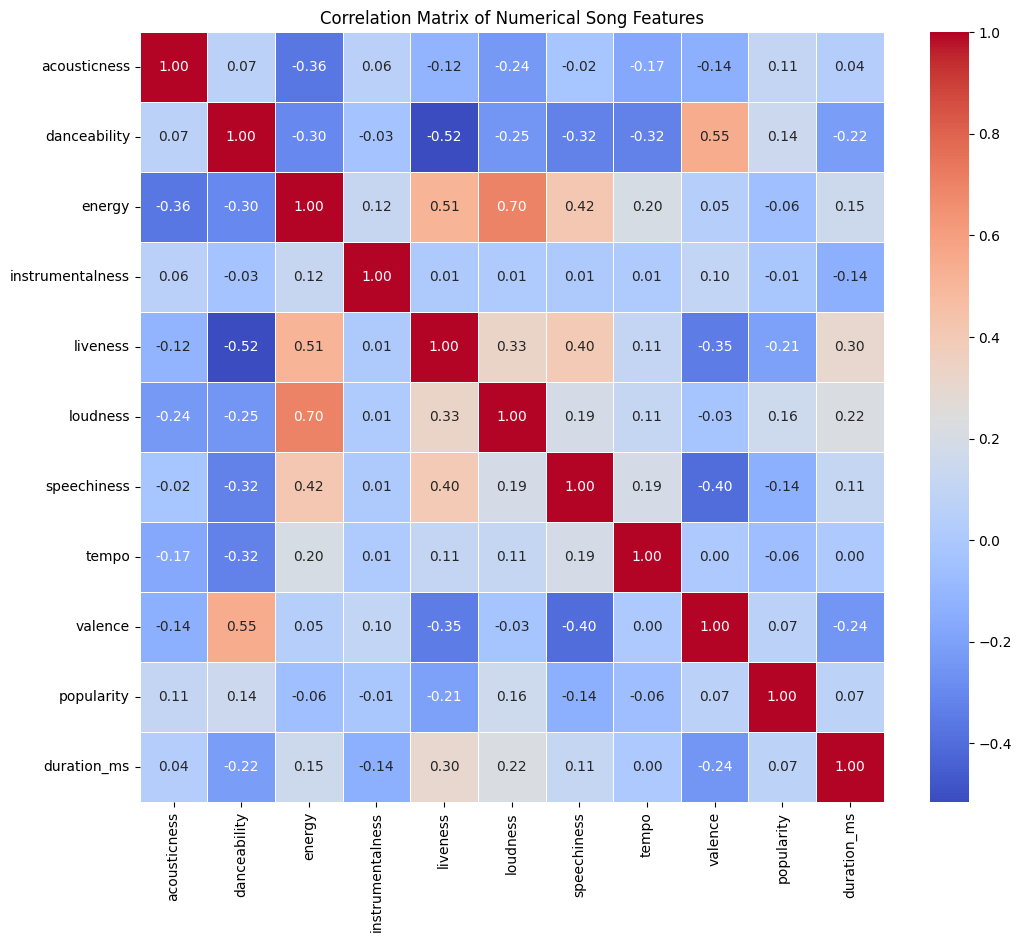

In [56]:
numerical_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness',
    'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms'
]

# Calculate the correlation matrix
correlation_matrix = data[numerical_features].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Song Features')
plt.show()

c.	Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved

In [57]:
# Extract the release year
data['release_year'] = data['release_date'].dt.year
print("DataFrame with 'release_year' column:")
data.head()

DataFrame with 'release_year' column:


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,is_popular,release_year
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640,False,2022
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173,False,2022
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160,False,2022
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880,False,2022
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106,False,2022


In [58]:
numerical_features_for_correlation = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness',
    'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms'
]

def calculate_popularity_correlation(df):
    # Calculate the correlation matrix for the specified numerical features
    correlation_matrix = df[numerical_features_for_correlation].corr()
    # Extract the 'popularity' column from the correlation matrix, excluding 'popularity' itself
    popularity_corr = correlation_matrix['popularity'].drop('popularity')
    return popularity_corr

# Group the data by 'release_year' and apply the function to each group
popularity_correlations_over_time = data.groupby('release_year').apply(calculate_popularity_correlation)

print("Correlation of Popularity with other features over time")
print(popularity_correlations_over_time.head())

Correlation of Popularity with other features over time
popularity    acousticness  danceability    energy  instrumentalness  \
release_year                                                           
1964              0.053334     -0.067692  0.061380         -0.038544   
1965              0.051618      0.007947 -0.030268         -0.048138   
1966              0.153383      0.350678 -0.289574         -0.079026   
1967              0.120534     -0.138009  0.031548          0.009551   
1968              0.031365      0.272056  0.201234         -0.043960   

popularity    liveness  loudness  speechiness     tempo   valence  duration_ms  
release_year                                                                    
1964          0.037058 -0.022315     0.103954  0.096531  0.004775     0.075224  
1965         -0.051159  0.004159    -0.073681  0.010458 -0.102093     0.243477  
1966         -0.347530 -0.324530    -0.105773 -0.013534  0.209219     0.091686  
1967          0.124895  0.175474  

In [60]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness',
    'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms'
]

# Select the numerical features from the DataFrame
features_to_scale = data[numerical_features]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
scaled_data = scaler.fit_transform(features_to_scale)

print("Shape of scaled_data:", scaled_data.shape)
print("First 5 rows of scaled_data:\n", scaled_data[:5])

Shape of scaled_data: (1610, 11)
First 5 rows of scaled_data:
 [[-0.73935481 -0.0413433   1.11576419  3.01209943  1.26155158 -1.98504535
   0.78440988 -0.27651662 -2.38759041  0.98299941 -1.9307186 ]
 [ 0.82051776 -1.00796305  0.96006155  0.24923772  1.34464824  0.72454468
   0.12375349  0.18385207 -1.14267825  1.06349527 -0.04213754]
 [ 0.72813952 -0.58462593  0.98230478  0.85395319  1.33032123  0.68010874
   0.88128032  0.1363233  -1.16430633  1.06349527  0.05007868]
 [ 1.39238306 -0.70457145  1.07127772 -0.59407965  1.15553171  0.47997995
   2.39245916  0.23651354 -1.88235852  0.90250356  0.44453914]
 [ 0.6577561  -1.17024228  0.98230478 -0.39205036  1.35897525  0.62598376
   0.45505039  0.1523031  -1.6271472   0.90250356  0.43739232]]


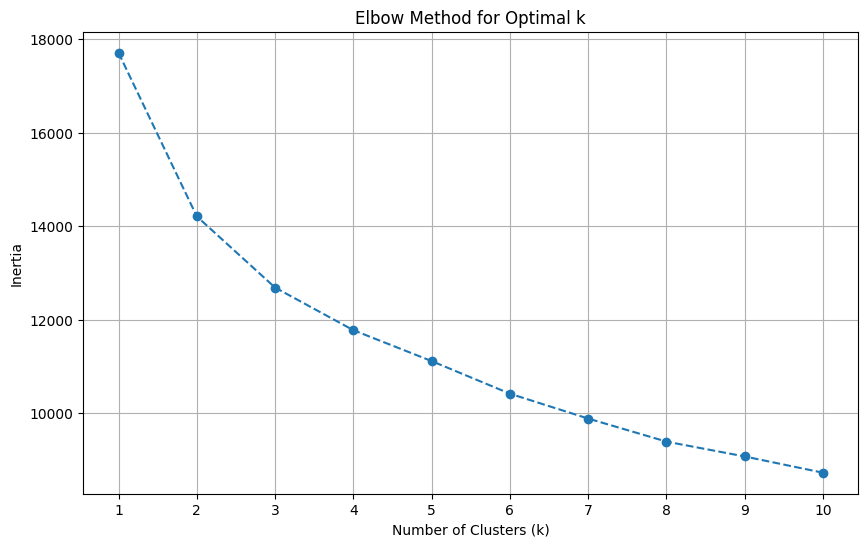

In [61]:
inertia_values = []
k_range = range(1, 11) # Trying k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to suppress warning
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

In [63]:
optimal_k = 3  # Based on the Elbow Method plot

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit KMeans to the scaled data
kmeans.fit(scaled_data)

# Get cluster labels and add them to the original DataFrame
data['cluster_label'] = kmeans.labels_

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("First 5 rows of data with cluster labels:")
print(data[['name', 'album', 'popularity', 'cluster_label']].head())

K-Means clustering applied with 3 clusters.
First 5 rows of data with cluster labels:
                          name               album  popularity  cluster_label
0   Concert Intro Music - Live  Licked Live In NYC          33              1
1   Street Fighting Man - Live  Licked Live In NYC          34              1
2           Start Me Up - Live  Licked Live In NYC          34              1
3  If You Can't Rock Me - Live  Licked Live In NYC          32              1
4            Don’t Stop - Live  Licked Live In NYC          32              1


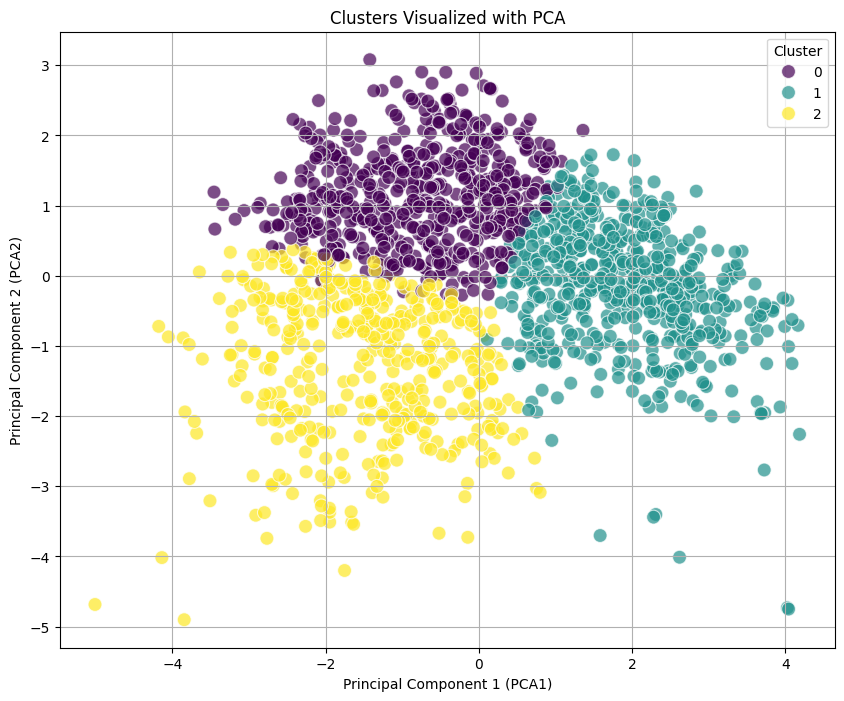

In [67]:
from sklearn.decomposition import PCA

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Fit and transform the scaled data
pca_components = pca.fit_transform(scaled_data)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df['cluster_label'] = data['cluster_label']

# Generate a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='cluster_label', data=pca_df,
    palette='viridis', s=100, alpha=0.7
)
plt.title('Clusters Visualized with PCA')
plt.xlabel('Principal Component 1 (PCA1)')
plt.ylabel('Principal Component 2 (PCA2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Data Analysis Key Findings
*   K-Means clustering was successfully applied using an optimal value of $k=3$ clusters, and the resulting cluster labels were added to the original dataset.
*   Analysis of the mean numerical feature values for each cluster revealed distinct characteristics:
    *   **Cluster 0** songs are generally characterized by higher `danceability` and `valence` (indicating more positive and danceable tracks).
    *   **Cluster 1** songs show very high `liveness` and `energy`, suggesting a more live performance feel and intense sound, but with lower `danceability` and `valence` compared to Cluster 0.
    *   **Cluster 2** songs are typically associated with lower `energy` and `loudness` values.

